In [7]:
import os

# 当 GPU 可用时，仅使用 1 个 GPU
os.environ["CUDA_VISIBLE_DEVICES"] = "0"

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from chronos import BaseChronosPipeline, Chronos2Pipeline

# 加载 Chronos-2 pipeline
# device_map:
# - cpu: 使用CPU
# - cuda: 使用GPU
pipeline: Chronos2Pipeline = BaseChronosPipeline.from_pretrained("amazon/chronos-2", device_map="cpu")

In [8]:
# 加载原始数据
all_df = pd.read_csv("data/project.csv")

print("数据维度:", all_df.shape)
display(all_df.head())

# 按 80/20 划分：前 80% 作为上下文，后 20% 作为真实值用于对比
split_idx = int(len(all_df) * 0.8)
context_df = all_df.iloc[:split_idx].copy()
test_df = all_df.iloc[split_idx:].copy()

print(f"\n上下文（前 80%）：{len(context_df)} 行，测试集（后 20%）：{len(test_df)} 行")

数据维度: (47, 3)


,item_id,timestamp,target
0,P,2022-03-01 00:00:00,1
1,P,2022-04-01 00:00:00,1
2,P,2022-05-01 00:00:00,1
3,P,2022-06-01 00:00:00,1
4,P,2022-07-01 00:00:00,2



上下文（前 80%）：37 行，测试集（后 20%）：10 行


In [9]:
# 预测长度与测试集长度对齐，以便与真实值对比
pred_df = pipeline.predict_df(context_df, prediction_length=len(test_df), quantile_levels=[0.1, 0.5, 0.9])

print("数据维度:", pred_df.shape)
display(pred_df.head())

数据维度: (10, 7)


,item_id,timestamp,target_name,predictions,0.1,0.5,0.9
0,P,2025-04-01,target,50.001190,45.999714,50.001190,52.663597
1,P,2025-05-01,target,51.310844,46.534058,51.310844,54.074158
2,P,2025-06-01,target,52.637196,47.250412,52.637196,55.997334
3,P,2025-07-01,target,54.012184,48.027237,54.012184,57.787060
4,P,2025-08-01,target,55.104786,48.588493,55.104786,60.085312


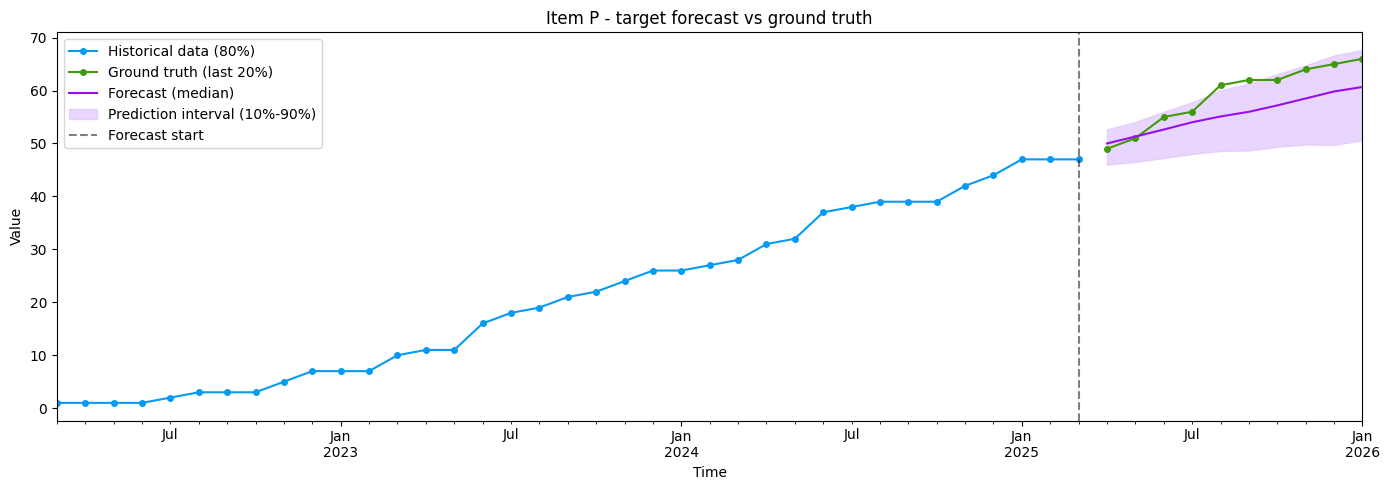

In [10]:
# 可视化预测后的数据（与后 20% 真实值对比）
item_id = "P"
target_column = "target"

ts_context = context_df.query("item_id == @item_id").set_index("timestamp")[target_column]
ts_test = test_df.query("item_id == @item_id").set_index("timestamp")[target_column]
ts_pred = pred_df.query("item_id == @item_id and target_name == @target_column").set_index("timestamp")[["0.1", "predictions", "0.9"]]

ts_context.index = pd.to_datetime(ts_context.index)
ts_test.index = pd.to_datetime(ts_test.index)
ts_pred.index = pd.to_datetime(ts_pred.index)

last_date = ts_context.index.max()

fig = plt.figure(figsize=(14, 5))
ax = fig.gca()

ts_context.plot(ax=ax, label=f"Historical data (80%)", color="xkcd:azure", marker="o", markersize=4)
ts_test.plot(ax=ax, label=f"Ground truth (last 20%)", color="xkcd:grass green", marker="o", markersize=4)
ts_pred["predictions"].plot(ax=ax, label="Forecast (median)", color="xkcd:violet")
ax.fill_between(
    ts_pred.index,
    ts_pred["0.1"],
    ts_pred["0.9"],
    alpha=0.7,
    label="Prediction interval (10%-90%)",
    color="xkcd:light lavender",
)
ax.axvline(x=last_date, color="black", linestyle="--", alpha=0.5, label="Forecast start")
ax.legend(loc="upper left")
ax.set_title(f"Item {item_id} - {target_column} forecast vs ground truth")
ax.set_xlabel("Time")
ax.set_ylabel("Value")
plt.tight_layout()
plt.show()


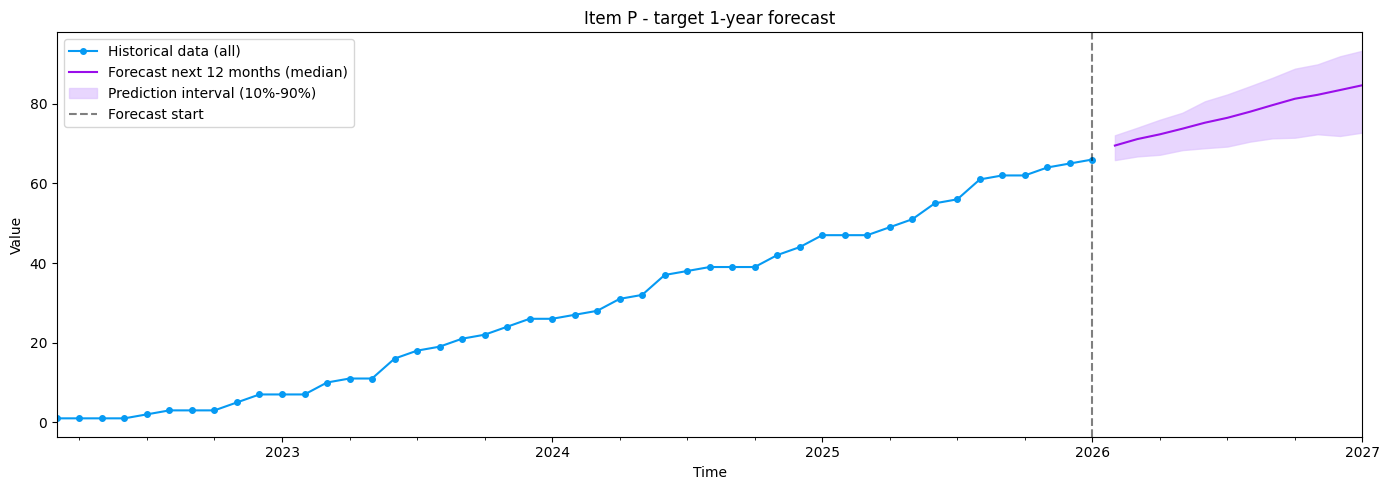


Forecast values:


,timestamp,predictions,0.1,0.9
0,2026-02-01,69.505455,65.858917,72.079399
1,2026-03-01,71.134468,66.780243,73.995094
2,2026-04-01,72.328255,67.193024,75.988914
3,2026-05-01,73.741791,68.362160,77.742867
4,2026-06-01,75.245270,68.847298,80.623474
5,2026-07-01,76.476807,69.258049,82.347092
6,2026-08-01,77.998215,70.490013,84.403442
7,2026-09-01,79.656471,71.325272,86.516655
8,2026-10-01,81.264915,71.482956,88.808182
9,2026-11-01,82.242973,72.351349,89.887680


In [11]:
# 使用全部数据预测未来 1 年（12 个月）
future_pred_df = pipeline.predict_df(all_df, prediction_length=12, quantile_levels=[0.1, 0.5, 0.9])

item_id = "P"
target_column = "target"

ts_all = all_df.query("item_id == @item_id").set_index("timestamp")[target_column]
ts_future = future_pred_df.query("item_id == @item_id and target_name == @target_column").set_index("timestamp")[["0.1", "predictions", "0.9"]]

ts_all.index = pd.to_datetime(ts_all.index)
ts_future.index = pd.to_datetime(ts_future.index)

last_date = ts_all.index.max()

fig = plt.figure(figsize=(14, 5))
ax = fig.gca()

ts_all.plot(ax=ax, label="Historical data (all)", color="xkcd:azure", marker="o", markersize=4)
ts_future["predictions"].plot(ax=ax, label="Forecast next 12 months (median)", color="xkcd:violet")
ax.fill_between(
    ts_future.index,
    ts_future["0.1"],
    ts_future["0.9"],
    alpha=0.7,
    label="Prediction interval (10%-90%)",
    color="xkcd:light lavender",
)
ax.axvline(x=last_date, color="black", linestyle="--", alpha=0.5, label="Forecast start")
ax.legend(loc="upper left")
ax.set_title(f"Item {item_id} - {target_column} 1-year forecast")
ax.set_xlabel("Time")
ax.set_ylabel("Value")
plt.tight_layout()
plt.show()

print("\nForecast values:")
display(future_pred_df[["timestamp", "predictions", "0.1", "0.9"]])